**Import the useful packages** 

In [1]:
# Import useful packages
import numpy as np
import xarray as xr
import glob
import matplotlib.pyplot as plt
import os,sys
import pandas as pd
# To avoid problems with tensorflow, add the following lines before importing it
import os
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
import tensorflow as tf
from tensorflow import keras
# To avoid problems with nn_functions, add the following lines before importing it 
import sys
sys.path.insert(1, '/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt')
#from nn_functions.constants import *
#import nn_functions.diagnostic_functions as diag
#import nn_functions.data_formatting as dfmt
import nn_functions.postprocessing_functions as pp
#from nn_functions.constants import *
# To import various params associated with the experiment exp_name
import define_params 
# For plotting things on the polar stereographic grid with lat and lon coordinates 
import cartopy.crs as ccrs
proj=ccrs.SouthPolarStereo(central_longitude=0.0)
trans=ccrs.PlateCarree()
import time

**Set the parameters for this specific run**

In [2]:
# Load in all the data
def load_test_data_whole_sim(this_collection, verbose = 0, keep_pandas = False):
    fp_apply = path_norm_metrics + this_collection + '_not_yet_normalised.csv'
    df_sel = pd.read_csv(fp_apply)
    print('\033[1m' + 'You have loaded data to apply the nn to:' + '\033[0m')
    print(fp_apply)
    print('You have kept the whole dataset')
    # Convert imported data to xarray
    if keep_pandas == False:
        clean_df = df_sel.to_xarray()
        return clean_df
    else:
        return df_sel

def load_test_data_val(this_collection, verbose = 0, keep_pandas = False):
    fp_apply = path_norm_metrics + this_collection + '_val_data.nc'
    df_sel = xr.open_dataset(fp_apply)
    df_sel = df_sel.sel(norm_method = norm_method).drop('norm_method')
    print('\033[1m' + 'You have loaded data to apply the nn to:' + '\033[0m')
    print(fp_apply)
    print('You have kept the whole dataset')
    if keep_pandas == False:
        return df_sel
    else:
        df_clean = df_sel.to_pandas()
        return df_clean

# Load in a trained neural network model
def load_model_nn(exp_name, this_collection, seed_nb, mod_size = 'small', TS_opt = 'extrap', norm_method = 'std', verbose = 0, 
                 annual_f = ''):
    fp_model = path_model + 'model_nn_'+ mod_size + '_' +exp_name + '_' + this_collection + '_' + annual_f + \
                                    str(seed_nb).zfill(2) + '_' + TS_opt + '_' + norm_method + '.keras'
    model = keras.models.load_model(fp_model)
    if verbose == 1:
        print('\033[1m' + 'You have loaded a trained neural network:' + '\033[0m')
        print(fp_model)
    return model

# Load in the normalisation metrics 
def load_normalisation_metrics(this_collection, norm_method = 'std', verbose = 0):
    fp_norm_metrics = path_norm_metrics + this_collection + '_metrics_norm.nc'
    norm_metrics_file = xr.open_dataset(fp_norm_metrics)
    if verbose > 0:
        print('\033[1m' + 'You have loaded normalisation metrics:' + '\033[0m')
        print(fp_norm_metrics)
    norm_metrics = norm_metrics_file.sel(norm_method=norm_method).drop('norm_method').to_dataframe()
    return norm_metrics

# Apply one trained NN to the chosen data 
def apply_model(model, norm_metrics, clean_df, exp_name, verbose = 0):
    # First normalise input data 
    val_norm = pp.normalise_vars(clean_df,
                            norm_metrics.loc['mean_vars'],
                            norm_metrics.loc['range_vars'])
    # Import the desired variables, and create a list 
    var_list = define_params.var_list_by_exp_name(exp_name)
    input_vars = list(np.array(var_list)[~(np.array(var_list) == 'melt_m_ice_per_y')])
    # Split into input and reference datasets
    x_val_norm = val_norm[input_vars]
    y_val_norm = val_norm['melt_m_ice_per_y']
    # Apply the model 
    #shape = x_val_norm.to_array().values.shape[1], x_val_norm.to_array().values.shape[0]
    #y_out_norm = model.predict(x_val_norm.to_array().values.reshape(shape),verbose = 0)
    y_out_norm = model.predict(x_val_norm.to_array().values.T,verbose = 0)
    y_out_norm_xr = xr.DataArray(data=y_out_norm.squeeze()).rename({'dim_0': 'index'})
    y_out_norm_xr = y_out_norm_xr.assign_coords({'index': x_val_norm.index})    
    # denormalise the output
    y_out = pp.denormalise_vars(y_out_norm_xr, 
                             norm_metrics['melt_m_ice_per_y'].loc['mean_vars'],
                             norm_metrics['melt_m_ice_per_y'].loc['range_vars'])
    if verbose > 0:
        print('\033[1m' + 'You have applied the neural network to the chosen data:' + '\033[0m')
    return y_out

# Apply all 10 NNs (with the 10 random seeds), and look at the mean 
def apply_nn_save_results(this_collection, exp_name, keep_all_runs = True, \
                         mod_size = 'small', TS_opt = 'extrap', norm_method = 'std', verbose = 0, annual_only = False, 
                         apply_collection = None, annual_f = ''):
    if apply_collection == None:
        load_collection = this_collection
    else:
        load_collection = apply_collection
    norm_metrics = load_normalisation_metrics(this_collection, verbose = verbose)
    clean_df = load_test_data_whole_sim(load_collection, verbose = verbose)
    if annual_only == True:
        # Get just the annual data 
        clean_pdf = clean_df.to_dataframe()
        df_annual = clean_pdf.groupby(['lat','lon','year'], as_index = False).mean()
        clean_df = df_annual.to_xarray()
    seed_nb_array = np.arange(1,11,1)
    list_melt_seeds = []
    df_ref_pred = pd.DataFrame({'lat': clean_df.lat, 
                                'lon': clean_df.lon,
                                'basin': clean_df.basins_NEMO,
                                'area': clean_df.area, #clean_df.approx_area for OPM026?
                                'year': clean_df.year, 
                                'month': clean_df.month, 
                                'melt_m_ice_per_y': clean_df.melt_m_ice_per_y})
    for i in range(len(seed_nb_array)):
        start_time = time.time()
        list_melt_seeds.append('melt_' + str(i+1).zfill(2))
        if verbose == 2:
            model = load_model_nn(exp_name, this_collection, seed_nb_array[i], \
                              mod_size = mod_size, TS_opt = TS_opt, norm_method = norm_method, \
                              verbose = 1, annual_f = annual_f) 
            df_ref_pred['melt_' + str(i+1).zfill(2)] = apply_model(model, norm_metrics, clean_df, exp_name, verbose = 1)
            end_time = time.time()
            print(seed_nb_array[i], 'out of', len(seed_nb_array), 'processed. Time: {:.0f} s'.format(end_time - start_time), end = '\r')
        else:
            model = load_model_nn(exp_name, this_collection, seed_nb_array[i], \
                              mod_size = mod_size, TS_opt = TS_opt, norm_method = norm_method, \
                              verbose = 0) 
            df_ref_pred['melt_' + str(i+1).zfill(2)] = apply_model(model, norm_metrics, clean_df, exp_name, verbose = 0)
            end_time = time.time()
            print(seed_nb_array[i], 'out of', len(seed_nb_array), 'processed. Time: {:.0f} s'.format(end_time - start_time), end = '\r')
    # Calculate the ensemble mean 
    df_ref_pred['melt_pred_mean'] = np.mean(df_ref_pred[list_melt_seeds], axis = 1).values
    
    # If you want to make the files smaller, you can save the results with just the ensemble mean
    # by setting keep_all_runs to False 
    if keep_all_runs == False:
        df_ref_pred_save = df_ref_pred[list(df_ref_pred.columns.values[~np.isin(list(df_ref_pred.columns.values), list_melt_seeds)])]
        print('Warning, you have not saved the results of each nn, just the ensemble mean')
        sims = 'just_mean'
    else:
        df_ref_pred_save = df_ref_pred
        print('You have saved the results of each nn, and the ensemble mean')
        sims = 'all_sims'
    # Set the filepath and save the output
    if annual_only == False:
        ano = ''
    else:
        ano = '_annual'
    if load_collection == True:
        lc = ''
    else:
        ano = ano + '_special_lc_' + load_collection
    fp_ref_pred = path_model + 'applied_nn' + '_' + mod_size + '_' +exp_name + '_' + this_collection + '_' + annual_f + \
                                        sims + '_' + TS_opt + '_' + norm_method + ano + '.csv'
    df_ref_pred.to_csv(fp_ref_pred, index = False)
    if verbose > 0:
        print('\033[1m' + 'You have saved the results of applying the neural network to the test dataset:' + '\033[0m')
        print(fp_ref_pred)

In [3]:
# Load in one year of data 

In [4]:
def load_geom_files(filepath_geomvars, filepath_mask, join_ice_shelves = False):
    geoms = xr.open_dataset(filepath_geomvars)
    masks = xr.open_dataset(filepath_mask)
    print('You have loaded:', filepath_geomvars)
    print('You have loaded:', filepath_mask)
    bN_00 = masks.basins_NEMO
    # Some ice shelves which should potentially be joined together into one bigger ice shelf
    if join_ice_shelves == True:
        # Dotson and Crosson?
        #basins_NEMO[basins_NEMO == 101] = 129
        # Abbot Ice Shelf
        bN_01 = xr.where(bN_00 == 109, 143, bN_00)
        # George VI
        bN_02 = xr.where(bN_01 == 112, 125, bN_01)
        # Lambert 
        basins_merged = xr.where(bN_02 == 20, 103, bN_02)
        print('Ice shelves joined, as requested')
    else:
        basins_merged = bN_00    
    return masks, basins_merged, geoms

In [62]:
def load_TSmelt_normal(filepath_nemo_output):
    # Load in the simulation files 
    gridT_varofint = xr.open_dataset(filepath_nemo_output)
    print('You have loaded:', filepath_nemo_output)
    # And cut out variables which are not needed
    gridT_varofint = gridT_varofint.squeeze('time_counter').sel(axis_nbounds=1).drop('time_counter').drop('time_centered')
    # Crop out most of the world and just save Antarctica 
    # Specify the coordinates needed
    min_lat = -52.2
    y_trim = np.max(np.argwhere(gridT_varofint.nav_lat[:,0].data <= min_lat))
    print('Cropped to Antarctica only')
    # Take this slice 
    gridT2 = gridT_varofint.sel(y = slice(0,y_trim+1))[['thetao','so', 'area', 'bathy', 'isf_draft']]
    # Close the original dataset
    so = gridT2.so
    thetao = gridT2.thetao
    #return so, thetao
    return gridT2

def load_gridcoords(filepath_nemo_output):
    # Load in the simulation files 
    gridT_varofint = xr.open_dataset(filepath_nemo_output)
    print('You have loaded:', filepath_nemo_output)
    # And cut out variables which are not needed
    gridT_varofint = gridT_varofint.squeeze('time_counter').drop('time_counter').drop('time_centered')
    # Crop out most of the world and just save Antarctica 
    # Specify the coordinates needed
    min_lat = -52.2
    y_trim = np.max(np.argwhere(gridT_varofint.nav_lat[:,0].data <= min_lat))
    print('Cropped to Antarctica only')
    # Take this slice 
    gridT2 = gridT_varofint.sel(y = slice(0,y_trim+1))[['bounds_nav_lon', 'bounds_nav_lat']]
    # Close the original dataset
    #so = gridT2.so
    #thetao = gridT2.thetao
    #return so, thetao
    return gridT2

In [6]:
#gridT_varofint

In [7]:
filepath_nemo_output = '/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/ECM71-ico-LR-pi-01.pi_1883_1Y_grid_T.nc'

In [8]:
#nemo_run = 'OPM016'
#year_of_interest = 1980
# Set the filepath for an example input file (note might have to change for monthly data?) 
#filepath_nemo_output = '/bettik/burgardc/DATA/BASAL_MELT_PARAM/raw/NEMO_eORCA025.L121-OPM016/' + 'eORCA025.L121-' + \
#                        nemo_run + '_y' + str(year_of_interest) + '.1y_gridT_varofint.nc'

# Set the filepath for the associated geometry file for the target ice shelves 
# (You will need to make this if it doesn't already exist...) 

# Set all the filepaths that will be required 
filepath_base = '/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/'
filepath_nn_input = filepath_base + "data/processing_ho/nn_input_"

#filepath_mask = filepath_base +  'AIAI_data/Masks/'+nemo_run+'_'+'geometric_masks.nc'
# A geometry file with the required variables for the NN 
#filepath_geomvars = filepath_base + 'AIAI_data/Masks/'+nemo_run+'_'+'geom_vars.nc'
#print(filepath_mask)
#print(filepath_geomvars)
# Load the masks and geoms needed 
#masks, basins_merged, geoms = load_geom_files(filepath_geomvars, filepath_mask, join_ice_shelves = True)

In [9]:
# Load the nemo_run requested 
gridT_varofint = xr.open_dataset(filepath_nemo_output)

In [10]:
#gridT_varofint

In [11]:
time_counter = gridT_varofint.time_counter.values[0]

In [102]:
#so, thetao = load_TSmelt_normal(filepath_nemo_output)
gridT2 = load_TSmelt_normal(filepath_nemo_output)
coords = load_gridcoords(filepath_nemo_output)

You have loaded: /bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/ECM71-ico-LR-pi-01.pi_1883_1Y_grid_T.nc
Cropped to Antarctica only
You have loaded: /bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/ECM71-ico-LR-pi-01.pi_1883_1Y_grid_T.nc
Cropped to Antarctica only


In [13]:
mask = ~np.isnan(gridT2.so.sel(deptht = 0, method = 'nearest').values)
# This mask is 1 for open ocean, 0 for others
mask2 = (np.nansum(gridT2.so, axis = 0) != 0)
# This mask is 1 for all ocean, 0 for others 

In [14]:
# Create masks for the ocean, closed cavities, open cavities, grounded ice 
ocean     = xr.where((mask == True), 1, 0)
ocean_nan = xr.where((mask == True), 1, np.nan)
open_cavities = xr.where((mask2 == True) & (mask != True), 1, 0)
open_cavities_nan = xr.where((mask2 == True) & (mask != True), 1, np.nan)
open_cav_ocean      = xr.where((ocean > 0.5),1, 0) + xr.where((open_cavities > 0.5), 1, 0)
open_cav_ocean_nan  = xr.where((open_cav_ocean == 1), 1, np.nan)
grounded_ice        = xr.where((open_cav_ocean) == 0, 1,0)
grounded_ice_nan    = xr.where((open_cav_ocean) == 0, 1,np.nan)
# Extract other useful parameters 
areas = gridT2.area
bathymetry = gridT2.bathy
isf_draft = gridT2.isf_draft

# Ideally would have a basins file specific for NEMO 1 degree?
ds0=xr.open_dataset('../MASKS_PARAM/basin_raster_extrapolate_eANT025.nc')
basins = ds0.basin[::4,::4]

In [15]:
nemo_run = 'OPM016'
# At this stage we need to also have the mask for the target grid 
filepath_mask = filepath_base +  'AIAI_data/Masks/'+nemo_run+'_'+'geometric_masks.nc'
# A geometry file with the required variables for the NN 
filepath_geomvars = filepath_base + 'AIAI_data/Masks/'+nemo_run+'_'+'geom_vars.nc'

In [16]:
mask25 = xr.open_dataset(filepath_mask)
mask25.lat.values.shape, mask25.lon.values.shape

((439, 1440), (439, 1440))

(-87.03863105773925, -62.0)

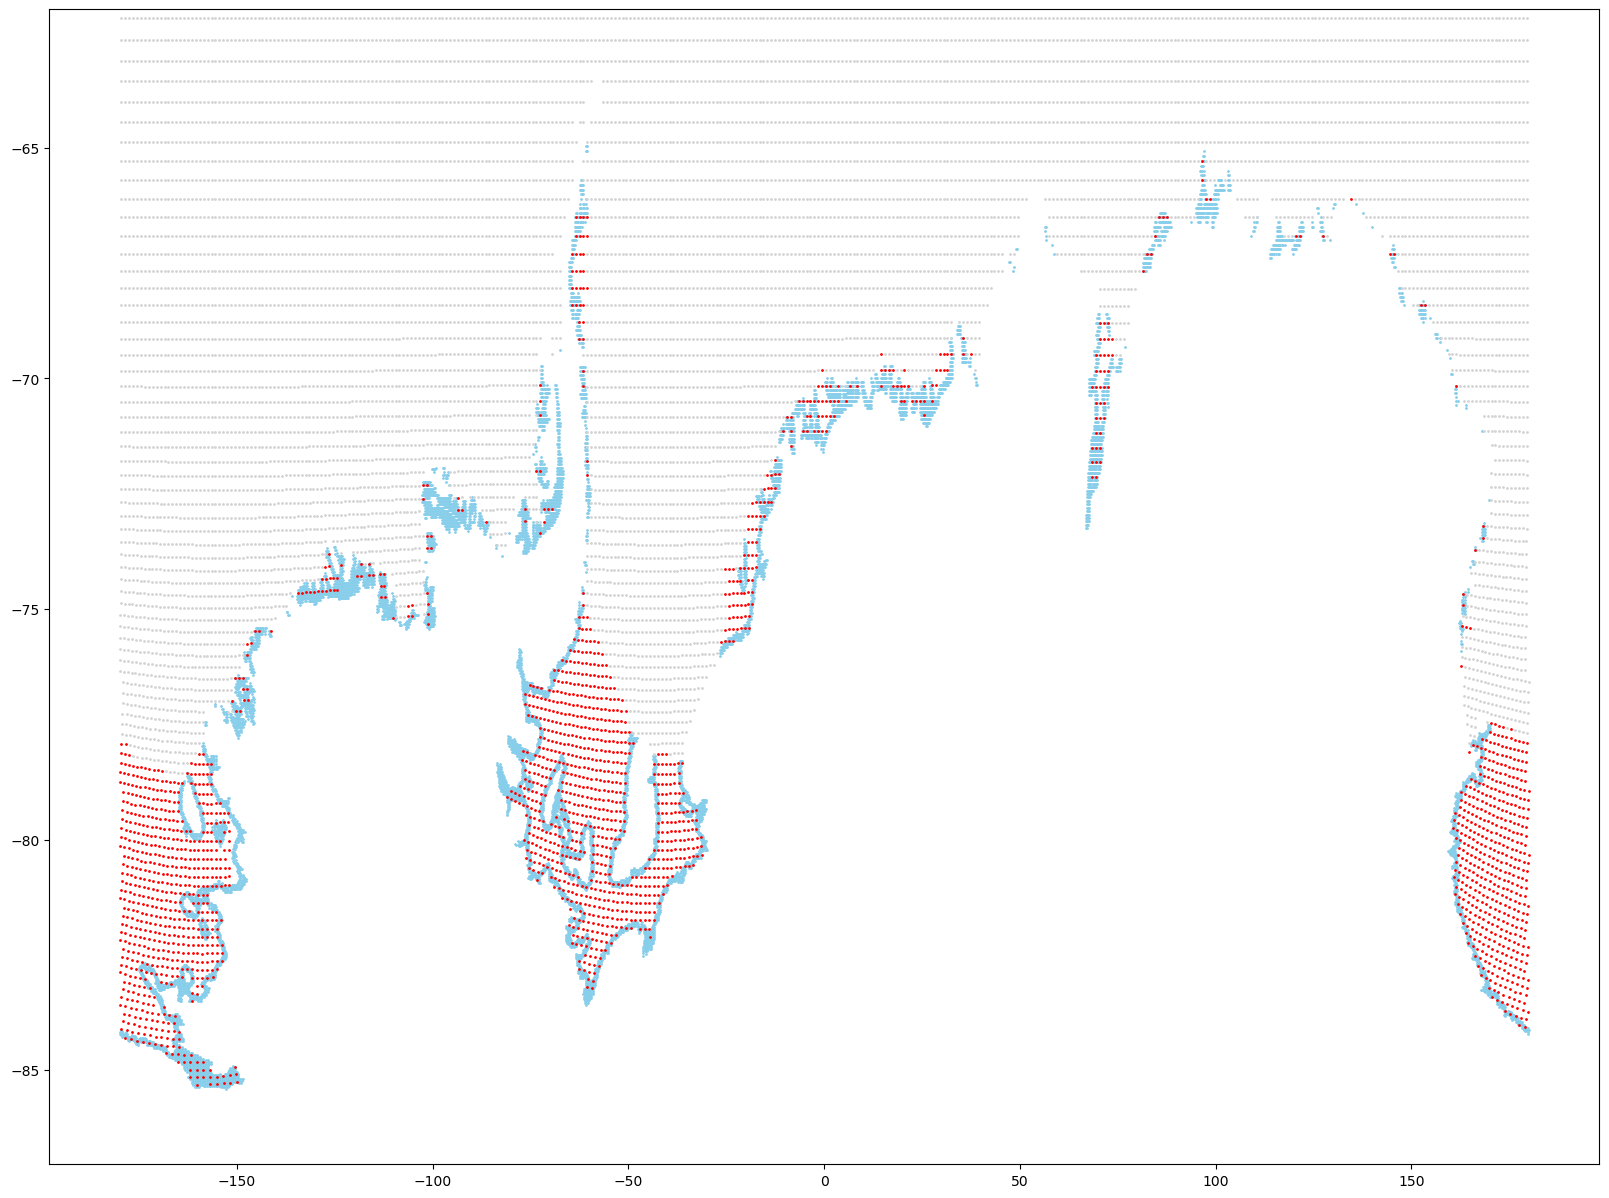

In [17]:
fig, ax = plt.subplots(1,1, figsize = (20,15))
plt.scatter(areas.nav_lon.values[open_cavities_nan == 1], areas.nav_lat.values[open_cavities_nan == 1], s = 1, c = 'red')
plt.scatter(areas.nav_lon.values[ocean_nan == 1], areas.nav_lat.values[ocean_nan == 1], s = 1, c = 'lightgrey')
plt.scatter(mask25.closed_cavities.lon.values[mask25.closed_cavities_nan == 1], \
            mask25.closed_cavities.lat.values[mask25.closed_cavities_nan == 1], s = 1, zorder = 0, c = 'skyblue') 
#            c = mask25.basins_NEMO.values[mask25.closed_cavities_nan == 1], zorder = 0)
plt.ylim(None, -62)

In [146]:
bmach3 = xr.open_dataset('../AIAI_data/BedMachineAntarctica-v3.nc')
d = 10
xbmach,ybmach = np.meshgrid(bmach3.x, bmach3.y)
#plt.imshow(bmach3.mask[::d,::d])

In [106]:
coords.bounds_nav_lon.sel(nvertex = 0)[i,j].values

array(-169.57277, dtype=float32)

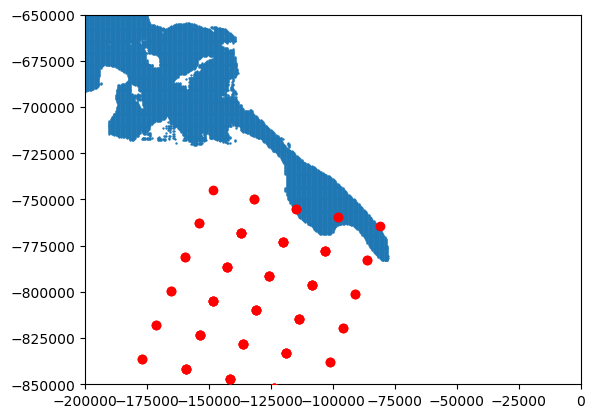

In [124]:
from pyproj import Transformer
transformer = Transformer.from_crs("epsg:4326","epsg:3031")
#transformer = Transformer.from_crs("epsg:3031","epsg:4326")
#x0, y0 = transformer.transform(Lakes['geometry'][0].exterior.xy[1],Lakes['geometry'][0].exterior.xy[0])


#i = 20
#j = 120
for i in (17,18,19,20,21, 22, 23):
    for j in (117,118,119,120):
        for jkl in (0,1,2,3):
            x2, y2 = transformer.transform(coords.bounds_nav_lat.sel(nvertex = jkl)[i,j].values, \
                                                   coords.bounds_nav_lon.sel(nvertex = jkl)[i,j].values)
#            print(x2, y2, coords.bounds_nav_lon.sel(nvertex = jkl)[i,j].values, \
#                                                   coords.bounds_nav_lat.sel(nvertex = jkl)[i,j].values)
            plt.scatter(x2, y2, c = 'red', zorder = 10)
#    plt.scatter(coords.bounds_nav_lon.sel(nvertex = 1)[i,j].values, coords.bounds_nav_lat.sel(nvertex = 1)[i,j].values, c = 'grey')
#    plt.scatter(coords.bounds_nav_lon.sel(nvertex = 2)[i,j].values, coords.bounds_nav_lat.sel(nvertex = 2)[i,j].values, c = 'k')
#    plt.scatter(coords.bounds_nav_lon.sel(nvertex = 3)[i,j].values, coords.bounds_nav_lat.sel(nvertex = 3)[i,j].values, c = 'orange')
plt.xlim(-0.20e6,-0.0e6)
plt.ylim(-0.85e6, -0.65e6)
plt.scatter(xbmach[bmach3.mask == value], ybmach[bmach3.mask == value], s = 0.5)

[ -81075.12448367  -97996.20317021 -103116.26209809  -86028.2684877 ] [-764429.43474924 -759747.21824472 -777942.79496287 -782654.39658192]


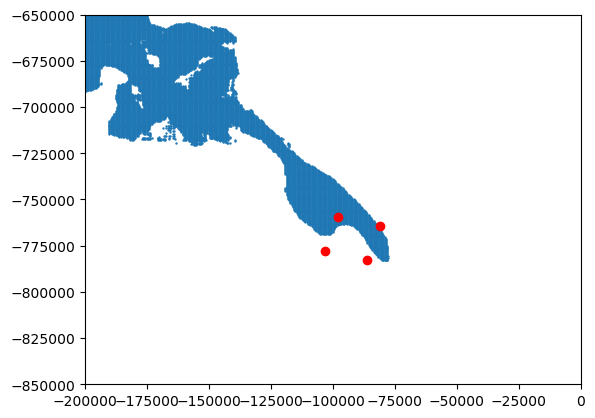

In [130]:
i = 17
j = 117
#for i in (17,18,19,20,21, 22, 23):
#    for j in (117,118,119,120):
x2 = np.ndarray(4)
y2 = np.ndarray(4)
for jkl in (0,1,2,3):
    x2[jkl], y2[jkl] = transformer.transform(coords.bounds_nav_lat.sel(nvertex = jkl)[i,j].values, \
                                           coords.bounds_nav_lon.sel(nvertex = jkl)[i,j].values)
print(x2, y2)
#            print(x2, y2, coords.bounds_nav_lon.sel(nvertex = jkl)[i,j].values, \
#                                                   coords.bounds_nav_lat.sel(nvertex = jkl)[i,j].values)

plt.scatter(x2, y2, c = 'red', zorder = 10)
#    plt.scatter(coords.bounds_nav_lon.sel(nvertex = 1)[i,j].values, coords.bounds_nav_lat.sel(nvertex = 1)[i,j].values, c = 'grey')
#    plt.scatter(coords.bounds_nav_lon.sel(nvertex = 2)[i,j].values, coords.bounds_nav_lat.sel(nvertex = 2)[i,j].values, c = 'k')
#    plt.scatter(coords.bounds_nav_lon.sel(nvertex = 3)[i,j].values, coords.bounds_nav_lat.sel(nvertex = 3)[i,j].values, c = 'orange')
plt.xlim(-0.20e6,-0.0e6)
plt.ylim(-0.85e6, -0.65e6)
plt.scatter(x[bmach3.mask == value], y[bmach3.mask == value], s = 0.5)

In [ ]:
import shapely.geometry as geom
import numpy as np

# Define square corners (list of (x,y))
corners = [(x2[0],y2[0]), (x2[1],y2[1]), (x2[2],y2[2]), (x2[3],y2[3])]  # replace with your coords
polygon = geom.Polygon(corners)

# Get coordinates from xarray
lon = xbmach[bmach3.mask == value]
lat = ybmach[bmach3.mask == value]

# Flatten and check each point
points = np.vstack([lon.ravel(), lat.ravel()]).T
points
mask = np.array([polygon.contains(geom.Point(p)) for p in points])


# Reshape mask to dataset shape
#mask = mask.reshape(lon.shape)

# Apply mask
#subset = bmach3.where(mask, drop=True)


In [ ]:
mask

In [138]:
import shapely.geometry as geom
import numpy as np

# Define square corners (list of (x,y))
corners = [(x2[0],y2[0]), (x2[1],y2[1]), (x2[2],y2[2]), (x2[3],y2[3])]  # replace with your coords
polygon = geom.Polygon(corners)

# Get coordinates from xarray
#x = x[bmach3.mask == value]
#y = y[bmach3.mask == value]

# Flatten and check each point
points = np.vstack([x[bmach3.mask == value].ravel(), y[bmach3.mask == value].ravel()]).T
print(points)

mask = np.array([polygon.contains(geom.Point(p)) for p in points])

# Reshape mask to dataset shape
mask = mask.reshape(x.shape)

# Apply mask
subset = ds.where(mask, drop=True)

IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

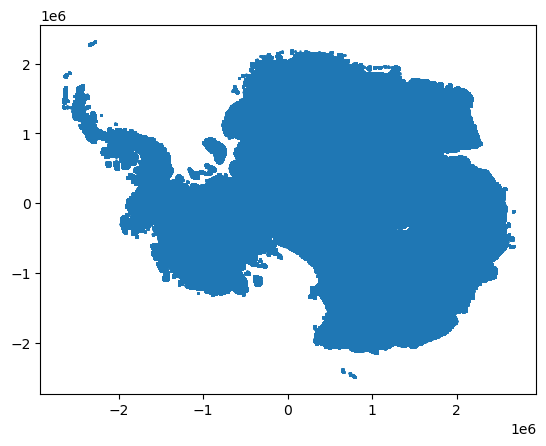

In [76]:
import itertools
#for i, j in itertools.product(range(gridT2.nav_lat.shape[0]), range(gridT2.nav_lon.shape[1])):
#    print(i,j)

(-94.49305877685546, -62.5)

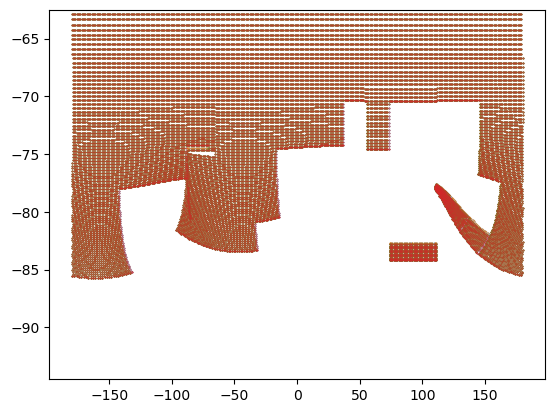

In [47]:
plt.scatter(gridT_varofint.sel(nvertex = 2).bounds_nav_lon.values, gridT_varofint.sel(nvertex = 2).bounds_nav_lat.values, s = 0.1)
plt.scatter(gridT_varofint.sel(nvertex = 3).bounds_nav_lon.values, gridT_varofint.sel(nvertex = 3).bounds_nav_lat.values, s = 0.1)
plt.scatter(gridT_varofint.sel(nvertex = 0).bounds_nav_lon.values, gridT_varofint.sel(nvertex = 0).bounds_nav_lat.values, s = 0.1)
plt.scatter(gridT_varofint.sel(nvertex = 1).bounds_nav_lon.values, gridT_varofint.sel(nvertex = 1).bounds_nav_lat.values, s = 0.1)
plt.ylim(None, -62.5)
#plt.xlim(-100,0)

In [27]:
gridT_varofint.bounds_nav_lon.where('nvertex' == 1)

<xarray.DataArray 'bounds_nav_lon' (y: 331, x: 360, nvertex: 4)>
array([[[nan, nan, nan, nan],
        [nan, nan, nan, nan],
        [nan, nan, nan, nan],
        ...,
        [nan, nan, nan, nan],
        [nan, nan, nan, nan],
        [nan, nan, nan, nan]],

       [[nan, nan, nan, nan],
        [nan, nan, nan, nan],
        [nan, nan, nan, nan],
        ...,
        [nan, nan, nan, nan],
        [nan, nan, nan, nan],
        [nan, nan, nan, nan]],

       [[nan, nan, nan, nan],
        [nan, nan, nan, nan],
        [nan, nan, nan, nan],
        ...,
...
        ...,
        [nan, nan, nan, nan],
        [nan, nan, nan, nan],
        [nan, nan, nan, nan]],

       [[nan, nan, nan, nan],
        [nan, nan, nan, nan],
        [nan, nan, nan, nan],
        ...,
        [nan, nan, nan, nan],
        [nan, nan, nan, nan],
        [nan, nan, nan, nan]],

       [[nan, nan, nan, nan],
        [nan, nan, nan, nan],
        [nan, nan, nan, nan],
        ...,
        [nan, nan, nan, nan],
        [nan, nan, nan, nan],
        [nan, nan, nan, nan]]], dtype=float32)
Coordinates:
    nav_lat  (y, x) float32 ...
    nav_lon  (y, x) float32 ...
Dimensions without coordinates: y, x, nvertex

In [ ]:
value = 2

In [22]:
gridT2.nav_lat, gridT2.nav_lon

(<xarray.DataArray 'nav_lat' (y: 110, x: 360)>
 array([[-84.21071 , -84.21071 , -84.21071 , ...,  -1.      ,  -1.      ,
          -1.      ],
        [-84.108955, -84.108955, -84.108955, ...,  -1.      ,  -1.      ,
          -1.      ],
        [-84.005424, -84.005424, -84.005424, ...,  -1.      ,  -1.      ,
          -1.      ],
        ...,
        [-53.75795 , -53.75795 , -53.75795 , ..., -53.75795 , -53.75795 ,
         -53.75795 ],
        [-53.162582, -53.162582, -53.162582, ..., -53.162582, -53.162582,
         -53.162582],
        [-52.558838, -52.558838, -52.558838, ..., -52.558838, -52.558838,
         -52.558838]], dtype=float32)
 Coordinates:
     nav_lat  (y, x) float32 -84.21 -84.21 -84.21 -84.21 ... -52.56 -52.56 -52.56
     nav_lon  (y, x) float32 73.5 74.5 75.5 76.5 77.5 ... 69.5 70.5 71.5 72.5
 Dimensions without coordinates: y, x
 Attributes:
     standard_name:  latitude
     long_name:      Latitude
     units:          degrees_north
     bounds:         bounds_

In [ ]:
from pyproj import Transformer
transformer = Transformer.from_crs("epsg:4326","epsg:3031")
x0, y0 = transformer.transform(Lakes['geometry'][0].exterior.xy[1],Lakes['geometry'][0].exterior.xy[0])
x1, y1 = transformer.transform(Lakes['geometry'][1].exterior.xy[1],Lakes['geometry'][1].exterior.xy[0])
x2, y2 = transformer.transform(Lakes['geometry'][2].exterior.xy[1],Lakes['geometry'][2].exterior.xy[0])
x3, y3 = transformer.transform(Lakes['geometry'][3].exterior.xy[1],Lakes['geometry'][3].exterior.xy[0])

In [ ]:
# What I need 
# For each grid cell, if any of the grid cell is in the 

(-2000000.0, 0.0)

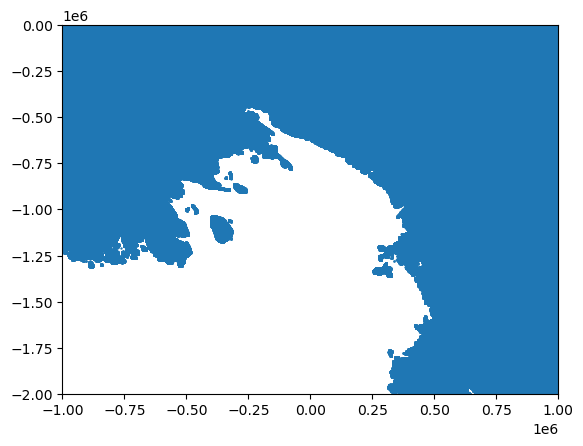

In [19]:
value = 2 # Ocean/ice/land mask: ocean (0); ice-free land (1); grounded ice (2); floating ice (3); Lake Vostok (4)
plt.scatter(x[bmach3.mask == value], y[bmach3.mask == value], s = 0.5)
#plt.pcolor(x,y,bmach3.mask)
#np.unique(bmach3.mask)
plt.xlim(-1e6,1e6)
plt.ylim(-2e6,0)


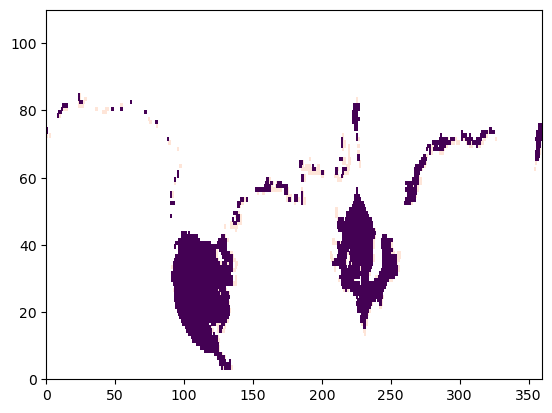

In [120]:
mask25 = xr.open_dataset(filepath_mask)
plt.pcolor(open_cavities_nan)
im = plt.pcolor(mask25.closed_cavities_nan[::4,::4], cmap = 'Reds_r', zorder = 0)
im.set_clim(0.1,1.1)

In [ ]:
# Create files of distances and slopes
# Create a pyproj transform to go from lat lon to polar stereo
transformer = Transformer.from_crs("epsg:4326","epsg:3031")

# Create a list of all the points in closed ice shelves 
CC_lat, CC_lon = dsREF.nav_lat.data[closed_cavities == 1], dsREF.nav_lon.data[closed_cavities == 1]
CC_x, CC_y = transformer.transform(CC_lat, CC_lon)
points_CC = np.array(list(zip(CC_x, CC_y)))
# Create a list of all the grounded ice points
GL_lat, GL_lon = dsREF.nav_lat.data[grounded_ice == 1], dsREF.nav_lon.data[grounded_ice == 1]
GL_x, GL_y = transformer.transform(GL_lat, GL_lon)
points_GL = np.array(list(zip(GL_x, GL_y)))
# Create a list of all the open ocean points 
OO_lat, OO_lon = dsREF.nav_lat.data[ocean == 1], dsREF.nav_lon.data[ocean == 1]
OO_x, OO_y = transformer.transform(OO_lat, OO_lon)
points_OO = np.array(list(zip(OO_x, OO_y)))
# Create a list of all the open ocean cavity points
OC_lat, OC_lon = dsREF.nav_lat.data[open_cav_ocean == 1], dsREF.nav_lon.data[open_cav_ocean == 1]
OC_x, OC_y = transformer.transform(OC_lat, OC_lon)
points_OC = np.array(list(zip(OC_x, OC_y)))

# Create the cKD Tree for the grounding line 
tree = cKDTree(points_GL)
# Query the cKD Tree for the closed cavity points 
dist, index = tree.query(points_CC, k = 1)
distances_GL = np.ones(dsREF.nav_lat.data.shape)*np.nan
distances_GL[closed_cavities == 1] = dist

# Create the cKD Tree for the open ocean
tree = cKDTree(points_OO)
# Query the cKD Tree for the closed cavity points 
dist, index = tree.query(points_CC, k = 1)
distances_OO = np.ones(dsREF.nav_lat.data.shape)*np.nan
distances_OO[closed_cavities == 1] = dist

# Create the cKD Tree for the open ocean and cavities
tree = cKDTree(points_OC)
# Query the cKD Tree for the closed cavity points 
dist, index = tree.query(points_CC, k = 1)
distances_OC = np.ones(dsREF.nav_lat.data.shape)*np.nan
distances_OC[closed_cavities == 1] = dist


In [24]:
#plt.pcolor(ds0.basin)
# Load in the data specifically needed here
#ds0=xr.open_dataset('basin_raster_extrapolate_eANT025.nc')
Nbasin=ds0.basin.max()
lon2d=dsREF.glamt.values
lat2d=dsREF.gphit.values
# to avoid hexagons in cartopy:
lon2d[lon2d>=180] = lon2d[lon2d>=180.] - 360.
delta_lon=np.abs(np.diff(lon2d))
for i, start in enumerate(np.argmax(delta_lon > 180, axis=1)):
  lon2d[i, start+1:] += 360
# Plot the data 
fig, axs = plt.subplots(nrows=1,ncols=1,
                        subplot_kw={'projection': proj},
                        figsize=(10.0,10.0))
#axs = axs.ravel()
# (lonmin, lonmax, latmin, latmax) :
axs.set_extent( (-180, 180, -88, -65), trans )
# Plot the basins as contour lines (probably a faster more efficient way to do this with a shapefile?
ds0.basin[0:1,:]=0.
for kbasin in np.arange(1,Nbasin+1,1):
  print(int(kbasin), 'out of', int(Nbasin.data), end = '\r')
  tmp = ds0.basin.values
  tmp = np.where(np.abs(tmp-kbasin)<0.1,1,0)
  axs.contour( lon2d, lat2d, tmp, [0.5], colors='k', linewidths=0.6, transform=trans )

TypeError: only integer scalar arrays can be converted to a scalar index

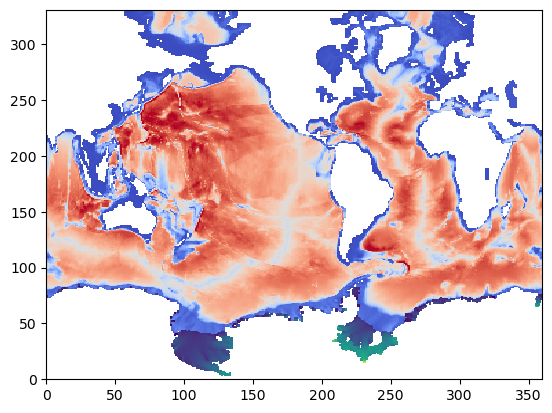

In [52]:
plt.pcolor(gridT_varofint.isf_draft, zorder = 1)
plt.pcolor(gridT_varofint.bathy, zorder = 0, cmap = 'coolwarm')

In [ ]:
fig, ax = plt.subplots(1,1, figsize = (5,6))
plt.imshow(mask2, cmap = 'coolwarm', alpha = 0.3, origin = 'lower')
plt.imshow(mask, cmap = 'cividis_r', alpha = 0.3, origin = 'lower')
plt.xlim(50,150)
plt.ylim(0,100)

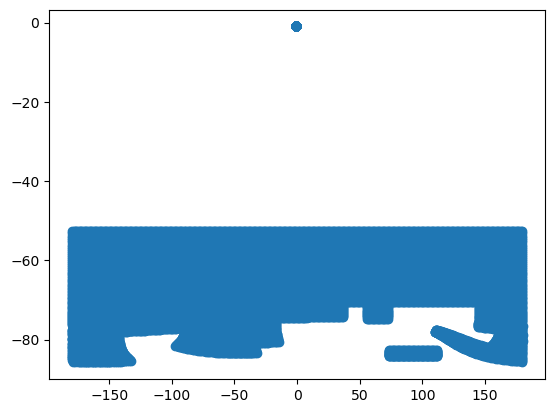

In [42]:
plt.scatter(so.nav_lon.values, so.nav_lat.values)

In [12]:
gridT_varofint.so

<xarray.DataArray 'so' (time_counter: 1, deptht: 75, y: 331, x: 360)>
[8937000 values with dtype=float32]
Coordinates:
    nav_lat        (y, x) float32 ...
    nav_lon        (y, x) float32 ...
  * deptht         (deptht) float32 0.5058 1.556 2.668 ... 5.698e+03 5.902e+03
    time_centered  (time_counter) object ...
  * time_counter   (time_counter) object 1883-07-02 12:00:00
Dimensions without coordinates: y, x
Attributes:
    standard_name:       sea_water_practical_salinity
    long_name:           sea_water_salinity
    units:               1e-3
    online_operation:    average
    interval_operation:  1 yr
    interval_write:      1 yr
    cell_methods:        time: mean time_counter: mean
    cell_measures:       area: area

In [4]:
# Generate one year of data to apply NN to 

In [ ]:
this_collection_apply = 'OPM0263_whole_dataset'

In [5]:
def load_test_data_whole_sim(this_collection, verbose = 0, keep_pandas = False):
    fp_apply = path_norm_metrics + this_collection + '_not_yet_normalised.csv'
    df_sel = pd.read_csv(fp_apply)
    print('\033[1m' + 'You have loaded data to apply the nn to:' + '\033[0m')
    print(fp_apply)
    print('You have kept the whole dataset')
    # Convert imported data to xarray
    if keep_pandas == False:
        clean_df = df_sel.to_xarray()
        return clean_df
    else:
        return df_sel

In [ ]:
fp_dataset = '/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/Training_data/'

In [7]:
path_norm_metrics = '/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/Training_data/'
load_test_data_whole_sim(this_collection_apply, verbose = 0, keep_pandas = False)

You have loaded data to apply the nn to:
/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/Training_data/OPM0263_whole_dataset_not_yet_normalised.csv
You have kept the whole dataset


<xarray.Dataset>
Dimensions:                 (index: 7831200)
Coordinates:
  * index                   (index) int64 0 1 2 3 ... 7831197 7831198 7831199
Data variables: (12/26)
    lat                     (index) float64 -85.37 -85.37 ... -65.08 -64.97
    lon                     (index) float64 -154.1 -153.7 ... -60.75 -60.75
    temperature_prop        (index) float64 -2.067 -2.067 ... -1.85 -1.426
    salinity_prop           (index) float64 34.9 34.9 34.9 ... 34.47 34.69 34.64
    melt_m_ice_per_y        (index) float64 -6.186e-05 -7.046e-05 ... -2.856e-05
    mean_T                  (index) float64 -2.081 -2.081 ... -1.638 -1.638
    ...                      ...
    slope_ba_lon            (index) float64 0.001152 -0.00235 ... -0.003905
    slope_ba_lat            (index) float64 0.005942 0.009487 ... 0.0 0.0
    slope_is_across_front   (index) float64 -0.002109 0.005645 ... -0.002396
    slope_is_towards_front  (index) float64 0.001439 0.003552 ... 0.0006687
    slope_ba_across_front   (index) float64 0.0043 0.003405 ... -0.003761
    slope_ba_towards_front  (index) float64 0.00426 0.009161 ... 0.00105

In [3]:
# Set the filepaths to useful files 
path_model = '/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/NN_models/'
path_norm_metrics = '/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/Training_data/'
models = glob.glob(path_model + '*.keras')
histories = glob.glob(path_model + 'history*.csv')

In [3]:
this_collection_NN = 'OPM026'
#this_collection_NN = 'OPM026'
this_collection_apply = 'OPM026_OPM0263_OPM031_OPM016_OPM018_OPM021_ctrl94_isf94_isfru94_whole_dataset'
exp_name = 'slope_front'

In [5]:
mod_size = 'small'
TS_opt = 'extrap'
norm_method = 'std'
annual_only = False, 
annual_f = ''

verbose = 2
norm_metrics = load_normalisation_metrics(this_collection_NN, verbose = verbose)
clean_df = load_test_data_val(this_collection_NN, verbose = verbose)



You have loaded normalisation metrics:
/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/Training_data/OPM026_OPM0263_OPM031_OPM016_OPM018_OPM021_ctrl94_isf94_isfru94_metrics_norm.nc
You have loaded data to apply the nn to:
/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/Training_data/OPM026_OPM0263_OPM031_OPM016_OPM018_OPM021_ctrl94_isf94_isfru94_val_data.nc
You have kept the whole dataset


In [6]:
df_clean = pp.denormalise_vars(clean_df,
                            norm_metrics.loc['mean_vars'],
                            norm_metrics.loc['range_vars'])
df_ref_pred = pd.DataFrame({'lat': df_clean.lat, 
                            'lon': df_clean.lon,
                            'basin': df_clean.basins_NEMO,
                            'area': df_clean.area, #clean_df.approx_area for OPM026?
                            'year': df_clean.year, 
                            'month': df_clean.month, 
                            'melt_m_ice_per_y': df_clean.melt_m_ice_per_y})

In [7]:
df_ref_pred

,lat,lon,basin,area,year,month,melt_m_ice_per_y
0,-67.103935,58.250000,22.0,1.169811e+08,2034.0,11.0,-7.711237e-04
1,-79.377800,-33.860794,82.0,3.096565e+07,2000.0,2.0,5.334456e-06
2,-84.748474,-162.277400,59.0,1.824226e+07,2022.0,4.0,-1.492573e-04
3,-78.827120,-36.642365,82.0,3.346525e+07,2013.0,NaN,-8.840067e-07
4,-82.200160,-47.377150,84.0,2.301701e+07,1989.0,1.0,1.058371e-06
...,...,...,...,...,...,...,...
4108244,-73.285970,-60.560574,117.0,6.385745e+07,2009.0,2.0,2.673496e-06
4108245,-70.332100,1.004222,9.0,8.612623e+07,2052.0,2.0,-4.412753e-04
4108246,-74.595770,-125.837456,108.0,5.295685e+07,1995.0,6.0,-1.647667e-05
4108247,-81.750810,-158.521060,58.0,2.408753e+07,1988.0,6.0,-3.440990e-07


In [8]:
def apply_model_val(model, norm_metrics, clean_df, exp_name, verbose = 0):
    # First normalise input data 
    val_norm = clean_df
    # Import the desired variables, and create a list 
    var_list = define_params.var_list_by_exp_name(exp_name)
    input_vars = list(np.array(var_list)[~(np.array(var_list) == 'melt_m_ice_per_y')])
    # Split into input and reference datasets
    x_val_norm = val_norm[input_vars]
    y_val_norm = val_norm['melt_m_ice_per_y']
    # Apply the model 
    #shape = x_val_norm.to_array().values.shape[1], x_val_norm.to_array().values.shape[0]
    #y_out_norm = model.predict(x_val_norm.to_array().values.reshape(shape),verbose = 0)
    y_out_norm = model.predict(x_val_norm.to_array().values.T,verbose = 0)
    y_out_norm_xr = xr.DataArray(data=y_out_norm.squeeze()).rename({'dim_0': 'index'})
    y_out_norm_xr = y_out_norm_xr.assign_coords({'index': x_val_norm.index})    
    # denormalise the output
    y_out = pp.denormalise_vars(y_out_norm_xr, 
                             norm_metrics['melt_m_ice_per_y'].loc['mean_vars'],
                             norm_metrics['melt_m_ice_per_y'].loc['range_vars'])
    if verbose > 0:
        print('\033[1m' + 'You have applied the neural network to the chosen data:' + '\033[0m')
    return y_out

In [ ]:
fp_ref_pred = path_model + 'applied_nn_' + this_collection_NN + '_val_data' + '.csv'

In [22]:
apply_model = False
if apply_model == True:
    seed_nb_array = np.arange(1,11,1)
    #seed_nb_array = np.arange(1,3,1)
    list_melt_seeds = []
    for i in range(len(seed_nb_array)):
        start_time = time.time()
        list_melt_seeds.append('melt_' + str(i+1).zfill(2))
        if verbose == 2:
            model = load_model_nn(exp_name, this_collection_NN, seed_nb_array[i], \
                              mod_size = mod_size, TS_opt = TS_opt, norm_method = norm_method, \
                              verbose = 1, annual_f = annual_f) 
            df_ref_pred['melt_' + str(i+1).zfill(2)] = apply_model_val(model, norm_metrics, clean_df, exp_name, verbose = 1)
            end_time = time.time()
            print(seed_nb_array[i], 'out of', len(seed_nb_array), 'processed. Time: {:.0f} s'.format(end_time - start_time), end = '\r')
    # Calculate the ensemble mean 
    df_ref_pred['melt_pred_mean'] = np.mean(df_ref_pred[list_melt_seeds], axis = 1).values

    df_ref_pred.to_csv(fp_ref_pred, index = False)
    if verbose > 0:
        print('\033[1m' + 'You have saved the results of applying the neural network to the test dataset:' + '\033[0m')
        print(fp_ref_pred)

In [12]:
from functions import regression_analysis, twosigfig

In [13]:
df_ref_pred = pd.read_csv(fp_ref_pred)

In [14]:
df_ref_ym = df_ref_pred.groupby(['basin'], as_index = False).mean()
RMSE = np.sqrt(np.mean((df_ref_ym.melt_m_ice_per_y- df_ref_ym.melt_pred_mean)**2))
R2 = regression_analysis(df_ref_ym.melt_m_ice_per_y, df_ref_ym.melt_pred_mean)[2]
print('RMSE:', RMSE*(60*60*24*365.25)/917, 'R2:', R2)

RMSE: 1.3807789987163017 R2: 0.9312734068237464


In [15]:
df_ref_ym = df_ref_pred.groupby(['lat','lon'], as_index = False).mean()
RMSE = np.sqrt(np.mean((df_ref_ym.melt_m_ice_per_y- df_ref_ym.melt_pred_mean)**2))
R2 = regression_analysis(df_ref_ym.melt_m_ice_per_y, df_ref_ym.melt_pred_mean)[2]
print('RMSE:', RMSE*(60*60*24*365.25)/917, 'R2:', R2)

RMSE: 1.1984633465663117 R2: 0.9717676927820474


In [16]:
df_ref_ym = df_ref_pred.groupby(['year','month'], as_index = False).mean()
RMSE = np.sqrt(np.mean((df_ref_ym.melt_m_ice_per_y- df_ref_ym.melt_pred_mean)**2))
R2 = regression_analysis(df_ref_ym.melt_m_ice_per_y, df_ref_ym.melt_pred_mean)[2]
print('RMSE:', RMSE*(60*60*24*365.25)/917, 'R2:', R2)

RMSE: 0.31376491829899705 R2: 0.9945921973403113


In [17]:
RMSE = np.sqrt(np.mean((df_ref_pred.melt_m_ice_per_y- df_ref_pred.melt_pred_mean)**2))
R2 = regression_analysis(df_ref_pred.melt_m_ice_per_y, df_ref_pred.melt_pred_mean)[2]
print('RMSE:', RMSE*(60*60*24*365.25)/917, 'R2:', R2)

RMSE: 3.2899567108707166 R2: 0.9306857152768183


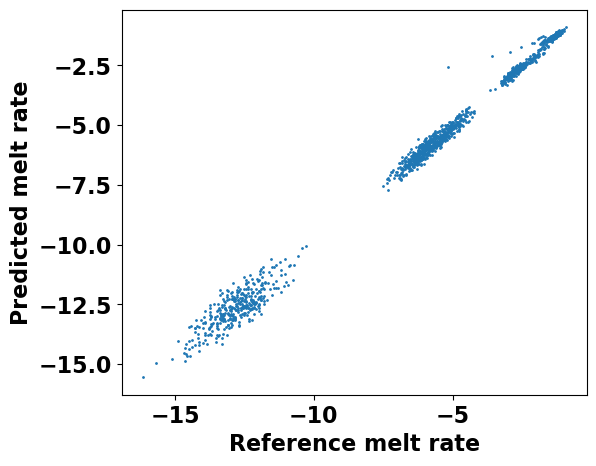

In [18]:
with plt.rc_context({'font.size': 16, 'font.weight': 'bold', 'axes.labelsize': 16, 'axes.labelweight': 'bold'}):
    fig, ax = plt.subplots(1,1, figsize = (6,5))
    ax.scatter(df_ref_ym.melt_m_ice_per_y*(60*60*24*365.25)/917, df_ref_ym.melt_01*(60*60*24*365.25)/917, s = 1)
    ax.set_ylabel('Predicted melt rate')
    ax.set_xlabel('Reference melt rate')
    plt.show()

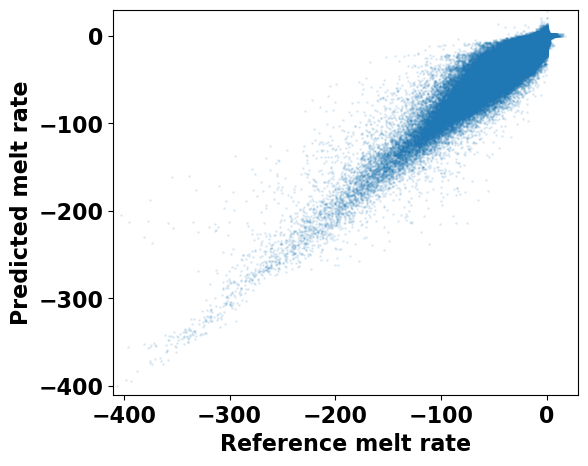

In [19]:
with plt.rc_context({'font.size': 16, 'font.weight': 'bold', 'axes.labelsize': 16, 'axes.labelweight': 'bold'}):
    fig, ax = plt.subplots(1,1, figsize = (6,5))
    ax.scatter(df_ref_pred.melt_m_ice_per_y*(60*60*24*365.25)/917, df_ref_pred.melt_01*(60*60*24*365.25)/917, s = 1, alpha = 0.1)
    ax.set_ylabel('Predicted melt rate')
    ax.set_xlabel('Reference melt rate')
    ax.set_xlim(-410,30)
    ax.set_ylim(-410,30)
    plt.show()